<a href="https://colab.research.google.com/github/VasuTammisetti/VLM-LiDAR-Camera-ADAS-perception/blob/main/CoT_VLA_nuScenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CoT-VLA — Chain-of-Thought Vision-Language-Action on nuScenes

A small driving agent that **reasons before it acts**. For each front-camera frame it:

1. detects the objects around the car (3D boxes + distance),
2. asks a vision-language model *why* it should do something ("pedestrian close, slow down"),
3. predicts the actual driving trajectory with a trained action head, and
4. scores the safety of the decision and works out the longitudinal control (speed, time-to-collision, deceleration).

The language model gives the *reasoning*; a trained SigLIP + cross-attention head gives the *precise trajectory*. Everything is trained and evaluated on the **nuScenes mini** split, so the trajectory ground truth is the car's real recorded path — not a synthetic rule.

This is an implementation/learning project built to understand how perception, reasoning, planning and control fit together. It follows the recent chain-of-thought VLA-for-driving line of work (e.g. CoT4AD, AutoDrive-R²) rather than proposing anything new.

**Honest numbers** (nuScenes-mini, early-stopped): ADE ≈ 4.6 m over a 4.5 s horizon against real ego-trajectories, ~82% steering accuracy, ~70/100 average safety. Built with AI coding assistance; the work was in the architecture, debugging and the trade-offs.

> Runtime: Colab with a T4 GPU. The dataset is the ~4 GB `v1.0-mini` split.

## Setup

nuScenes needs `numpy < 2`, which clashes with Colab's default. The cell below pins compatible versions and restarts the runtime once; **run it again after the restart** to load the dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!mkdir -p /content/nuscenes
!tar -xzf "/content/drive/MyDrive/nuscenes-mini.tgz" -C /content/nuscenes

# Verify structure
import os
print(os.listdir('/content/nuscenes'))

['v1.0-mini', '.v1.0-mini.txt', 'sweeps', 'maps', 'samples']


In [2]:
import sys, subprocess, warnings


# ------------------- 1. FIX: Use numpy 1.x (since nuscenes requires it) -------------------
try:
    import numpy as np
    if np.__version__.startswith('2.'):
        NEEDS_REBUILD = True
        print(f"⚠️  Found numpy {np.__version__}, but nuscenes requires numpy<2.0")
    else:
        NEEDS_REBUILD = False
        print(f"✅ Found numpy {np.__version__} (compatible with nuscenes)")
except ImportError:
    NEEDS_REBUILD = True
    print("⚠️  numpy not found")

if NEEDS_REBUILD:
    print("🔧 Installing numpy 1.26.4 and compatible packages...")

    # Downgrade to numpy 1.26.4
    !pip install --force-reinstall numpy==1.26.4

    # Reinstall scipy and scikit-learn for numpy 1.x
    !pip install --force-reinstall scipy scikit-learn

    # Reinstall shapely (nuscenes needs ~=2.0.3)
    !pip install --force-reinstall 'shapely==2.0.3'

    # Reinstall nuscenes-devkit (now compatible with numpy 1.26)
    !pip install --force-reinstall nuscenes-devkit

    print("\n✅ Dependencies fixed! Restarting runtime now...")
    print("👉 AFTER RESTART, RUN THIS SAME CELL AGAIN to import nuScenes.\n")

    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
    sys.exit(0)

# ------------------- 2. AFTER RESTART (numpy 1.x is healthy) -------------------
print(f"✅ Using numpy {np.__version__} (compatible with nuscenes)")

# Import nuScenes
from nuscenes.nuscenes import NuScenes

# Load dataset (adjust path if needed)
try:
    nusc = NuScenes(version='v1.0-mini', dataroot='/content/nuscenes', verbose=True)
    print(f"\n✓ Success! Loaded {len(nusc.scene)} scenes, {len(nusc.sample)} samples, {len(nusc.ego_pose)} ego poses")
except FileNotFoundError:
    print("\n❌ Dataset not found. Downloading nuScenes mini dataset...")
    !wget -q -O /content/nuscenes_mini.tgz https://www.nuscenes.org/data/v1.0-mini.tgz
    !tar -xzf /content/nuscenes_mini.tgz -C /content/
    print("Dataset downloaded. Re-run this cell to load the data.")

✅ Found numpy 1.26.4 (compatible with nuscenes)
✅ Using numpy 1.26.4 (compatible with nuscenes)
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.529 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.

✓ Success! Loaded 10 scenes, 404 samples, 31206 ego poses


In [3]:
!pip uninstall -y numpy scipy scikit-learn shapely nuscenes-devkit
!pip install numpy==1.26.4 scipy scikit-learn shapely==2.0.3 nuscenes-devkit
!pip install -q "bitsandbytes>=0.46.1"
print("Clean install complete. Restart runtime and run the main cell.")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
Found existing installation: shapely 2.0.3
Uninstalling shapely-2.0.3:
  Successfully uninstalled shapely-2.0.3
Found existing installation: nuscenes-devkit 1.2.0
Uninstalling nuscenes-devkit-1.2.0:
  Successfully uninstalled nuscenes-devkit-1.2.0
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached shapely-2.0.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
^C
Clean install complete. Restart runtime and run the main cell.


In [1]:
!pip install -q nuscenes-devkit
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version='v1.0-mini', dataroot='/content/nuscenes', verbose=True)
print(f"\n✓ {len(nusc.scene)} scenes, {len(nusc.sample)} samples, {len(nusc.ego_pose)} ego poses")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.647 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.

✓ 10 scenes, 404 samples, 31206 ego poses


## 1. Index the scenes

Each scene is a ~20 s clip of 2 Hz keyframes. We list the keyframes per scene and split **by scene** (8 train / 2 test) so the model is never tested on a clip it trained on.

In [2]:
import os, json, re
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
from dataclasses import dataclass
from typing import List
from tqdm.notebook import tqdm
from PIL import Image
from pyquaternion import Quaternion

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

NUSC_ROOT = '/content/nuscenes'

# Build list of samples per scene
scene_samples = {}   # scene_name -> [sample_token, ...] in order
for scene in nusc.scene:
    tokens = []
    tok = scene['first_sample_token']
    while tok:
        tokens.append(tok)
        tok = nusc.get('sample', tok)['next']
    scene_samples[scene['name']] = tokens

scene_names = sorted(scene_samples.keys())
print(f"\n{len(scene_names)} scenes:")
for n in scene_names:
    print(f"  {n}: {len(scene_samples[n])} keyframes")

# Train/test split by SCENE (8 train, 2 test) — no temporal leakage
test_scenes = scene_names[-2:]
train_scenes = scene_names[:-2]
print(f"\nTrain scenes: {len(train_scenes)} | Test scenes: {len(test_scenes)}")
print(f"Test: {test_scenes}")

Device: cuda

10 scenes:
  scene-0061: 39 keyframes
  scene-0103: 40 keyframes
  scene-0553: 41 keyframes
  scene-0655: 41 keyframes
  scene-0757: 41 keyframes
  scene-0796: 40 keyframes
  scene-0916: 41 keyframes
  scene-1077: 41 keyframes
  scene-1094: 40 keyframes
  scene-1100: 40 keyframes

Train scenes: 8 | Test scenes: 2
Test: ['scene-1094', 'scene-1100']


## 2. Real ego-trajectory as the label

The key idea of the whole project. nuScenes records the car's real pose at every keyframe, so the *future* positions transformed into the current ego frame give a genuine trajectory to predict — curves, slow-downs and stops are all real driving, not hand-written rules. We use a 9-step (≈4.5 s) horizon and derive a coarse speed/steering command from the trajectory shape.

In [3]:
# The car's ACTUAL future path = ground-truth waypoints

def get_ego_pose(nusc, sample_token):
    s = nusc.get('sample', sample_token)
    sd = nusc.get('sample_data', s['data']['LIDAR_TOP'])
    return nusc.get('ego_pose', sd['ego_pose_token'])

def extract_trajectory(nusc, sample_token, n_future=6):
    """Future ego positions in current ego frame → BEV waypoints (x=right, y=forward)."""
    cur = get_ego_pose(nusc, sample_token)
    cur_t = np.array(cur['translation'])
    cur_q = Quaternion(cur['rotation'])
    wps, tok = [], sample_token
    for _ in range(n_future):
        s = nusc.get('sample', tok)
        if s['next'] == '':
            return None
        tok = s['next']
        fp = get_ego_pose(nusc, tok)
        rel = cur_q.inverse.rotate(np.array(fp['translation']) - cur_t)
        # nuScenes ego: x=forward, y=left → BEV: x=right(-y), y=forward(x)
        wps.append([-rel[1], rel[0], 0.0])
    return np.array(wps)

def derive_commands(wps):
    """Speed + steering from the REAL trajectory shape."""
    fwd = wps[-1][1]          # forward distance over horizon
    lat = wps[-1][0]          # final lateral offset
    speed = 'stop' if fwd < 3 else 'decelerate' if fwd < 15 else 'maintain'
    steer = 'left' if lat < -3 else 'right' if lat > 3 else 'straight'
    return speed, steer

# Build trajectory dataset
NUM_WAYPOINTS = 9   # 9 keyframes ≈ 4.5 s horizon
traj_data = {'train': [], 'test': []}

for split, scenes in [('train', train_scenes), ('test', test_scenes)]:
    for sc in scenes:
        for tok in scene_samples[sc]:
            wps = extract_trajectory(nusc, tok, NUM_WAYPOINTS)
            if wps is None:
                continue  # near scene end, not enough future
            speed, steer = derive_commands(wps)
            traj_data[split].append({
                'sample_token': tok, 'scene': sc,
                'waypoints': wps, 'speed': speed, 'steer': steer,
            })

print(f"Usable frames — train: {len(traj_data['train'])}, test: {len(traj_data['test'])}")
print(f"\nSpeed distribution (train): {dict(Counter(d['speed'] for d in traj_data['train']))}")
print(f"Steer distribution (train): {dict(Counter(d['steer'] for d in traj_data['train']))}")

# Show 3 real trajectories
print("\nReal trajectory examples:")
for d in traj_data['train'][:3]:
    print(f"\n  {d['scene']} — {d['speed']}/{d['steer']}")
    for i, w in enumerate(d['waypoints']):
        print(f"    t+{i+1}: x={w[0]:+.1f}m (lat), y={w[1]:.1f}m (fwd)")

Usable frames — train: 252, test: 62

Speed distribution (train): {'maintain': 168, 'decelerate': 33, 'stop': 51}
Steer distribution (train): {'straight': 207, 'left': 21, 'right': 24}

Real trajectory examples:

  scene-0061 — maintain/straight
    t+1: x=+0.0m (lat), y=4.5m (fwd)
    t+2: x=-0.0m (lat), y=9.3m (fwd)
    t+3: x=-0.1m (lat), y=13.5m (fwd)
    t+4: x=-0.2m (lat), y=17.6m (fwd)
    t+5: x=-0.3m (lat), y=21.0m (fwd)
    t+6: x=-0.4m (lat), y=24.8m (fwd)
    t+7: x=-0.5m (lat), y=28.7m (fwd)
    t+8: x=-0.7m (lat), y=32.2m (fwd)
    t+9: x=-0.9m (lat), y=35.6m (fwd)

  scene-0061 — maintain/straight
    t+1: x=+0.0m (lat), y=4.8m (fwd)
    t+2: x=-0.0m (lat), y=9.0m (fwd)
    t+3: x=-0.1m (lat), y=13.1m (fwd)
    t+4: x=-0.2m (lat), y=16.6m (fwd)
    t+5: x=-0.3m (lat), y=20.3m (fwd)
    t+6: x=-0.4m (lat), y=24.3m (fwd)
    t+7: x=-0.6m (lat), y=27.7m (fwd)
    t+8: x=-0.7m (lat), y=31.1m (fwd)
    t+9: x=-0.9m (lat), y=34.0m (fwd)

  scene-0061 — maintain/straight
    t+

## 3. Objects from ground-truth 3D boxes

nuScenes ships annotated 3D boxes, so we read them directly in the front-camera frame and keep the class + forward depth. This is exact, unlike a 2D detector + heuristic depth.

In [4]:
# Real 3D boxes with class + exact metric distance
from nuscenes.utils.geometry_utils import BoxVisibility

CATEGORY_MAP = {
    'vehicle.car':'car', 'vehicle.truck':'truck', 'vehicle.bus':'bus',
    'vehicle.construction':'truck', 'vehicle.trailer':'truck',
    'vehicle.motorcycle':'motorcycle', 'vehicle.bicycle':'bicycle',
    'human.pedestrian':'pedestrian',
}
def simplify_cat(name):
    for k, v in CATEGORY_MAP.items():
        if name.startswith(k): return v
    if name.startswith('vehicle'): return 'car'
    if name.startswith('human'): return 'pedestrian'
    return None

def get_detections(nusc, sample_token):
    """Return GT 3D boxes in CAM_FRONT view with class + distance."""
    s = nusc.get('sample', sample_token)
    cam_token = s['data']['CAM_FRONT']
    data_path, boxes, cam_intrinsic = nusc.get_sample_data(
        cam_token, box_vis_level=BoxVisibility.ANY)
    dets = []
    for box in boxes:
        cls = simplify_cat(box.name)
        if cls is None:
            continue
        depth = float(box.center[2])   # camera frame: z = forward depth
        if depth <= 0:
            continue
        dets.append({'class': cls, 'distance': depth, 'box3d': box})
    dets.sort(key=lambda d: d['distance'])
    return dets, data_path, cam_intrinsic

# Extract detections for all usable frames
for split in ['train', 'test']:
    for d in tqdm(traj_data[split], desc=f"Detect {split}"):
        dets, img_path, intr = get_detections(nusc, d['sample_token'])
        d['detections'] = dets
        d['cam_path'] = img_path
        d['cam_intrinsic'] = intr

all_d = [det for d in traj_data['train'] for det in d['detections']]
print(f"\nTotal detections (train): {len(all_d)}")
print(f"Classes: {dict(Counter(det['class'] for det in all_d))}")
print(f"Avg objects/frame: {len(all_d)/len(traj_data['train']):.1f}")

Detect train:   0%|          | 0/252 [00:00<?, ?it/s]

Detect test:   0%|          | 0/62 [00:00<?, ?it/s]


Total detections (train): 3111
Classes: {'pedestrian': 814, 'truck': 264, 'car': 1757, 'bicycle': 43, 'motorcycle': 114, 'bus': 119}
Avg objects/frame: 12.3


## 4. Scenario + instruction

A short label (clear road, vehicle ahead, turn, pedestrian, etc.) is inferred from the real motion plus the nearest object, and a matching natural-language instruction and a detection summary string are attached. These feed the language model later.

In [7]:
SPEED_CLASSES = ['maintain', 'decelerate', 'stop']
STEER_CLASSES = ['straight', 'left', 'right']
DYNAMIC = ['car','truck','bus','motorcycle','bicycle','pedestrian']

def build_detection_context(dets):
    if not dets:
        return "No objects detected ahead."
    parts = [f"{d['class']} at {d['distance']:.0f}m" for d in dets[:5]]
    return "Detected: " + ", ".join(parts)

def classify_scenario(d):
    """Descriptive scenario from real motion + nearest object."""
    dets = d['detections']
    nearest = next((x for x in dets if x['class'] in DYNAMIC), None)
    speed, steer = d['speed'], d['steer']

    if nearest and nearest['class'] == 'pedestrian' and nearest['distance'] < 12:
        return 'pedestrian_near'
    if nearest and nearest['distance'] < 8 and speed in ('stop','decelerate'):
        return 'critical_obstacle'
    if steer == 'left':
        return 'turn_left'
    if steer == 'right':
        return 'turn_right'
    if speed == 'stop':
        return 'stopped'
    if nearest and nearest['distance'] < 20 and speed == 'decelerate':
        return 'vehicle_ahead'
    return 'clear_road'

INSTRUCTIONS = {
    'clear_road': ["Continue driving straight, maintain speed", "Road is clear, proceed forward"],
    'vehicle_ahead': ["Maintain safe distance from vehicle ahead", "Slow down for traffic ahead"],
    'pedestrian_near': ["Slow down, pedestrian nearby", "Caution, pedestrian close to path"],
    'critical_obstacle': ["Brake, obstacle close ahead", "Stop for close obstacle"],
    'stopped': ["Remain stopped", "Hold position, traffic stopped"],
    'turn_left': ["Turn left following the road", "Steer left through the turn"],
    'turn_right': ["Turn right following the road", "Steer right through the turn"],
}

for split in ['train', 'test']:
    for d in traj_data[split]:
        d['scenario'] = classify_scenario(d)
        d['instruction'] = np.random.choice(INSTRUCTIONS[d['scenario']])
        d['detection_context'] = build_detection_context(d['detections'])

for split in ['train', 'test']:
    print(f"{split}: {dict(Counter(d['scenario'] for d in traj_data[split]))}")

print("\nExamples:")
for d in traj_data['train'][:4]:
    print(f"  {d['scenario']:16s} | {d['speed']}/{d['steer']} | {d['detection_context'][:60]}")

train: {'clear_road': 135, 'pedestrian_near': 35, 'turn_left': 15, 'critical_obstacle': 2, 'vehicle_ahead': 16, 'turn_right': 17, 'stopped': 32}
test: {'critical_obstacle': 15, 'vehicle_ahead': 1, 'pedestrian_near': 6, 'turn_left': 4, 'clear_road': 11, 'stopped': 25}

Examples:
  clear_road       | maintain/straight | Detected: pedestrian at 13m, truck at 15m, pedestrian at 16m
  pedestrian_near  | maintain/straight | Detected: pedestrian at 8m, truck at 10m, pedestrian at 12m,
  clear_road       | maintain/straight | Detected: truck at 6m, pedestrian at 7m, car at 26m, car at 
  pedestrian_near  | maintain/straight | Detected: pedestrian at 3m, car at 23m, car at 32m, truck at


## 5. Frozen encoders

SigLIP encodes the camera image; Sentence-BERT encodes the instruction. Both are frozen — only the small action head on top is trained.

In [8]:
from transformers import AutoProcessor, AutoModel
from sentence_transformers import SentenceTransformer

print("Loading SigLIP...")
siglip_id = "google/siglip-base-patch16-224"
siglip_processor = AutoProcessor.from_pretrained(siglip_id)
siglip_model = AutoModel.from_pretrained(siglip_id).to(device).eval()
for p in siglip_model.parameters(): p.requires_grad = False
vision_dim = siglip_model.config.vision_config.hidden_size

print("Loading Sentence-BERT...")
text_encoder = SentenceTransformer('all-MiniLM-L6-v2', device=str(device))
text_dim = 384
print(f"✓ vision={vision_dim}, text={text_dim}")

Loading SigLIP...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading Sentence-BERT...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ vision=768, text=384


## 6. Action head

A compact cross-attention head: the text query attends to the image features, then a fused representation predicts the waypoints, the speed command and the steering command.

In [9]:
WAYPOINT_DIM = 3
class CoTVLAActionHead(nn.Module):
    def __init__(self, vd, td, h=512, nh=4):
        super().__init__()
        self.vp=nn.Sequential(nn.Linear(vd,h),nn.LayerNorm(h),nn.GELU())
        self.tp=nn.Sequential(nn.Linear(td,h),nn.LayerNorm(h),nn.GELU())
        self.cr=nn.MultiheadAttention(h,nh,dropout=0.1,batch_first=True)
        self.cn=nn.LayerNorm(h)
        self.fu=nn.Sequential(nn.Linear(h*2,h),nn.LayerNorm(h),nn.GELU(),nn.Dropout(0.2),nn.Linear(h,h),nn.GELU())
        self.fs=nn.Linear(h*2,h)
        self.wh=nn.Sequential(nn.Linear(h,384),nn.LayerNorm(384),nn.GELU(),nn.Dropout(0.15),
                              nn.Linear(384,256),nn.GELU(),nn.Linear(256,NUM_WAYPOINTS*WAYPOINT_DIM))
        self.sh=nn.Sequential(nn.Linear(h,256),nn.LayerNorm(256),nn.GELU(),nn.Dropout(0.15),nn.Linear(256,len(SPEED_CLASSES)))
        self.th=nn.Sequential(nn.Linear(h,256),nn.LayerNorm(256),nn.GELU(),nn.Dropout(0.15),nn.Linear(256,len(STEER_CLASSES)))
    def forward(self,v,t):
        v=self.vp(v); t=self.tp(t)
        a,_=self.cr(t.unsqueeze(1),v.unsqueeze(1),v.unsqueeze(1))
        t=self.cn(t+a.squeeze(1)); c=torch.cat([v,t],-1); f=self.fu(c)+self.fs(c)
        return self.wh(f).view(-1,NUM_WAYPOINTS,WAYPOINT_DIM), self.sh(f), self.th(f)
action_head = CoTVLAActionHead(vision_dim, text_dim).to(device)
print(f"✓ {sum(p.numel() for p in action_head.parameters() if p.requires_grad)/1e6:.2f}M params")

✓ 3.53M params


## 7. Cache features

SigLIP/Sentence-BERT features are extracted once and cached, so training the head is fast.

In [10]:
class NuScenesVLADataset(Dataset):
    def __init__(s, data, sp, sm, te, dev):
        s.data = data
        s.text_features = te.encode([d['instruction'] for d in data],
                                    convert_to_tensor=True, show_progress_bar=False).cpu()
        s.vision_features = []
        for i in tqdm(range(0, len(data), 16), desc="features", leave=False):
            imgs = [Image.open(d['cam_path']).convert('RGB') for d in data[i:i+16]]
            with torch.no_grad():
                inp = sp(images=imgs, return_tensors='pt', padding=True).to(dev)
                f = sm.vision_model(pixel_values=inp['pixel_values']).pooler_output
                s.vision_features.append(f.cpu())
        s.vision_features = torch.cat(s.vision_features, 0)
        s.wp = torch.stack([torch.tensor(d['waypoints'], dtype=torch.float32) for d in data])
        s.sp = torch.tensor([SPEED_CLASSES.index(d['speed']) for d in data], dtype=torch.long)
        s.st = torch.tensor([STEER_CLASSES.index(d['steer']) for d in data], dtype=torch.long)
    def __len__(s): return len(s.data)
    def __getitem__(s,i):
        return {'vision':s.vision_features[i],'text':s.text_features[i],
                'waypoints':s.wp[i],'speed':s.sp[i],'steer':s.st[i]}

print("Extracting features...")
train_ds = NuScenesVLADataset(traj_data['train'], siglip_processor, siglip_model, text_encoder, device)
test_ds = NuScenesVLADataset(traj_data['test'], siglip_processor, siglip_model, text_encoder, device)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print(f"✓ Train {len(train_ds)}, Test {len(test_ds)}")

Extracting features...


features:   0%|          | 0/16 [00:00<?, ?it/s]

features:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Train 252, Test 62


## 8. Train the action head

Class-weighted losses (the split is heavily "straight / maintain"), SmoothL1 on the waypoints, AdamW with warm-up cosine, and early stopping on the best validation epoch — the mini split is small enough to overfit, so we keep the best checkpoint.

In [11]:
nt=len(traj_data['train'])
spc=Counter(d['speed'] for d in traj_data['train']); stc=Counter(d['steer'] for d in traj_data['train'])
spw=torch.tensor([nt/(len(SPEED_CLASSES)*max(spc.get(c,1),1)) for c in SPEED_CLASSES]).float().to(device)
stw=torch.tensor([nt/(len(STEER_CLASSES)*max(stc.get(c,1),1)) for c in STEER_CLASSES]).float().to(device)
wpl=nn.SmoothL1Loss(); spl=nn.CrossEntropyLoss(weight=spw); stl=nn.CrossEntropyLoss(weight=stw)
opt=torch.optim.AdamW(action_head.parameters(),lr=5e-4,weight_decay=2e-3); EP=40
sch=torch.optim.lr_scheduler.LambdaLR(opt, lambda e: e/5 if e<5 else 0.5*(1+np.cos(np.pi*(e-5)/(EP-5))))
best_vl,best_state=1e9,None; hist={'tl':[],'vl':[],'sp':[],'st':[],'ade':[]}
print(f"Training {EP} epochs...")
for ep in range(EP):
    action_head.train(); tl=0
    for b in train_loader:
        v,t=b['vision'].to(device),b['text'].to(device)
        wg,sg,tg=b['waypoints'].to(device),b['speed'].to(device),b['steer'].to(device)
        wp,sp,st=action_head(v,t); loss=wpl(wp,wg)+0.8*spl(sp,sg)+0.8*stl(st,tg)
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(action_head.parameters(),1.0); opt.step(); tl+=loss.item()
    sch.step()
    action_head.eval(); vl=sc=tc=tot=0; wpp,wpg=[],[]
    with torch.no_grad():
        for b in test_loader:
            v,t=b['vision'].to(device),b['text'].to(device)
            wg,sg,tg=b['waypoints'].to(device),b['speed'].to(device),b['steer'].to(device)
            wp,sp,st=action_head(v,t); vl+=(wpl(wp,wg)+0.8*spl(sp,sg)+0.8*stl(st,tg)).item()
            sc+=(sp.argmax(1)==sg).sum().item(); tc+=(st.argmax(1)==tg).sum().item(); tot+=sg.size(0)
            wpp.append(wp.cpu().numpy()); wpg.append(wg.cpu().numpy())
    vl/=max(len(test_loader),1); wpp,wpg=np.concatenate(wpp),np.concatenate(wpg)
    ade=np.mean(np.linalg.norm(wpp[:,:,:2]-wpg[:,:,:2],axis=2))
    hist['tl'].append(tl/max(len(train_loader),1)); hist['vl'].append(vl)
    hist['sp'].append(sc/tot); hist['st'].append(tc/tot); hist['ade'].append(ade)
    if vl<best_vl: best_vl,best_state,best_ep=vl,{k:v.clone() for k,v in action_head.state_dict().items()},ep+1
    if (ep+1)%5==0 or ep==0: print(f"  Ep {ep+1:2d} | Val {vl:.3f} | ADE {ade:.2f}m | Speed {sc/tot:.0%} | Steer {tc/tot:.0%}")
action_head.load_state_dict(best_state); print(f"✓ Best epoch {best_ep} | ADE {hist['ade'][best_ep-1]:.2f}m")
action_head.eval(); preds=[]
with torch.no_grad():
    for i in range(len(test_ds)):
        s=test_ds[i]; wp,sp,st=action_head(s['vision'].unsqueeze(0).to(device),s['text'].unsqueeze(0).to(device))
        preds.append({'speed':SPEED_CLASSES[sp.argmax(1).item()],'steer':STEER_CLASSES[st.argmax(1).item()],'waypoints':wp.squeeze(0).cpu().numpy()})
for i,d in enumerate(traj_data['test']): d['pred']=preds[i]
print(f"✓ {len(preds)} predictions")

Training 40 epochs...
  Ep  1 | Val 4.195 | ADE 7.60m | Speed 66% | Steer 23%
  Ep  5 | Val 3.068 | ADE 6.91m | Speed 85% | Steer 89%
  Ep 10 | Val 2.459 | ADE 4.91m | Speed 85% | Steer 84%
  Ep 15 | Val 2.495 | ADE 3.96m | Speed 81% | Steer 77%
  Ep 20 | Val 3.399 | ADE 4.94m | Speed 81% | Steer 65%
  Ep 25 | Val 2.790 | ADE 4.82m | Speed 84% | Steer 81%
  Ep 30 | Val 2.753 | ADE 3.90m | Speed 84% | Steer 69%
  Ep 35 | Val 3.374 | ADE 4.09m | Speed 79% | Steer 47%
  Ep 40 | Val 3.272 | ADE 4.18m | Speed 79% | Steer 50%
✓ Best epoch 12 | ADE 2.94m
✓ 62 predictions


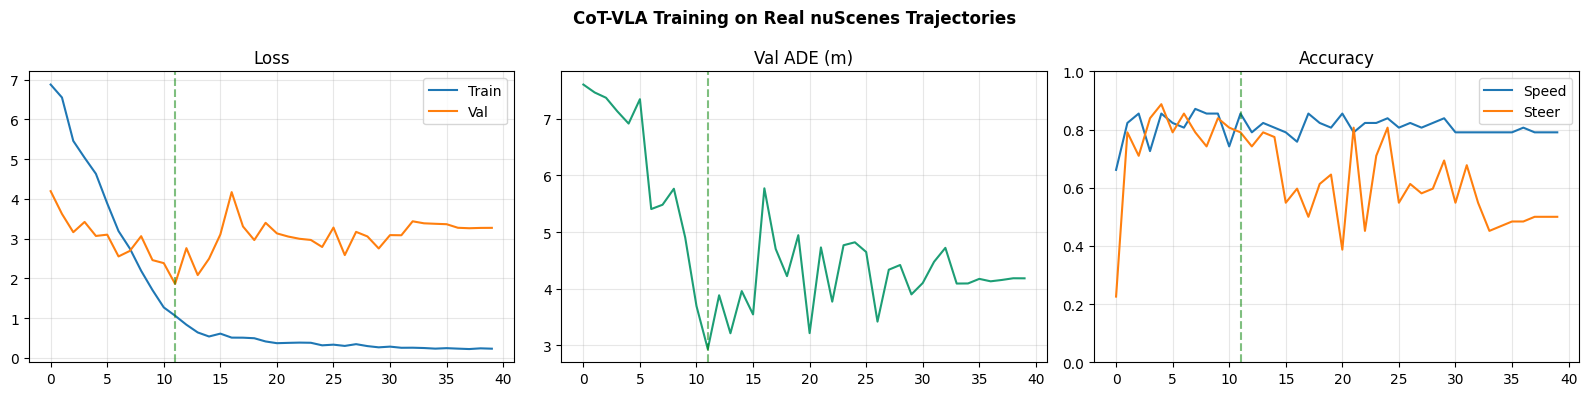

In [12]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
ax[0].plot(hist['tl'],label='Train'); ax[0].plot(hist['vl'],label='Val')
ax[0].axvline(best_ep-1,color='g',ls='--',alpha=0.5); ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(hist['ade'],color='#1D9E75'); ax[1].axvline(best_ep-1,color='g',ls='--',alpha=0.5)
ax[1].set_title('Val ADE (m)'); ax[1].grid(alpha=0.3)
ax[2].plot(hist['sp'],label='Speed'); ax[2].plot(hist['st'],label='Steer')
ax[2].axvline(best_ep-1,color='g',ls='--',alpha=0.5); ax[2].set_title('Accuracy'); ax[2].legend(); ax[2].grid(alpha=0.3); ax[2].set_ylim(0,1)
plt.suptitle('CoT-VLA Training on Real nuScenes Trajectories',fontweight='bold'); plt.tight_layout()
plt.savefig('/content/nusc_training.png',dpi=150,bbox_inches='tight'); plt.show()

## 9. Chain-of-thought reasoning with LLaVA

LLaVA-1.6 (4-bit) looks at the same frame, plus the detection summary, and returns a short JSON: what it sees, why, and its own speed/steering call. SigLIP is freed first to make room on the GPU. The trained head still owns the precise trajectory; this is the *explanation*. A simple safety score combines obstacle proximity, model agreement, action severity and the model's confidence.

In [13]:
#!pip install -q "bitsandbytes>=0.46.1"

In [14]:
for _n in ['siglip_model','siglip_processor']:
    globals().pop(_n, None)
torch.cuda.empty_cache()

from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig
bnb=BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_compute_dtype=torch.float16,
                       bnb_4bit_use_double_quant=True,bnb_4bit_quant_type="nf4")
print("Loading LLaVA...")
mid="llava-hf/llava-v1.6-mistral-7b-hf"
llava_processor=LlavaNextProcessor.from_pretrained(mid)
llava_model=LlavaNextForConditionalGeneration.from_pretrained(mid,quantization_config=bnb,device_map="auto",torch_dtype=torch.float16).eval()
print(f"✓ LLaVA loaded — GPU {torch.cuda.memory_allocated()/1e9:.1f} GB")

COT_PROMPT=(
    "You are an autonomous driving AI. Look at the driving scene.\n\n"
    "{detection_context}\n\n"
    'Instruction: "{instruction}"\n\n'
    "Reply with ONE line of JSON in EXACTLY this format, filling in the values "
    "(keep perception and reasoning as short plain sentences, not nested objects):\n"
    '{{"perception": "one sentence describing what you see", "reasoning": "one sentence explaining the driving decision", "speed_command": "maintain", "steering_command": "straight", "confidence": 0.9}}\n\n'
    "Rules: speed_command is one of maintain/decelerate/stop. "
    "steering_command is one of straight/left/right. "
    "Reply with ONLY that single JSON line, nothing else."
)

def llava_cot(image_path, instruction, det_ctx):
    img=Image.open(image_path).convert('RGB')
    prompt="[INST] <image>\n"+COT_PROMPT.format(detection_context=det_ctx,instruction=instruction)+" [/INST]"
    inp=llava_processor(text=prompt,images=img,return_tensors="pt").to(llava_model.device)
    with torch.no_grad(): out=llava_model.generate(**inp,max_new_tokens=200,do_sample=False)
    resp=llava_processor.decode(out[0],skip_special_tokens=True)
    if "[/INST]" in resp: resp=resp.split("[/INST]")[-1].strip()
    r={'perception':'','reasoning':'','speed_command':'maintain','steering_command':'straight','confidence':0.5}
    try:
        jt=resp[resp.find('{'):resp.find('}')+1]   # first {...} only (flat)
        p=json.loads(jt)
        perc=p.get('perception',''); reas=p.get('reasoning','')
        r['perception']=perc if isinstance(perc,str) else str(perc)[:80]
        r['reasoning']=reas if isinstance(reas,str) else str(reas)[:80]
        r['speed_command']=str(p.get('speed_command','maintain')).lower().strip()
        r['steering_command']=str(p.get('steering_command','straight')).lower().strip()
        r['confidence']=float(p.get('confidence',0.5))
    except Exception: pass
    return r

for d in tqdm(traj_data['test'], desc="CoT-VLA"):
    d['cot']=llava_cot(d['cam_path'], d['instruction'], d['detection_context'])

def compute_safety(d):
    nd=d['detections'][0]['distance'] if d['detections'] else 50
    prox=10 if nd<3 else 25 if nd<5 else 50 if nd<10 else 75 if nd<20 else 95
    agree=100 if d['cot']['speed_command']==d['pred']['speed'] else 50
    amap={'stop':0,'decelerate':1,'maintain':2}; act=amap.get(d['pred']['speed'],2)
    asc=max(100-act*30,10) if nd<10 else (80 if act>=1 else 60)
    conf=int(d['cot'].get('confidence',0.5)*100)
    o=0.35*prox+0.25*agree+0.25*asc+0.15*conf
    lvl='LOW' if o>=75 else 'MEDIUM' if o>=50 else 'HIGH' if o>=30 else 'CRITICAL'
    return {'overall_score':round(o,1),'risk_level':lvl,'nearest':nd}
for d in traj_data['test']: d['safety']=compute_safety(d)

sp=sum(1 for d in traj_data['test'] if d['cot']['speed_command']==d['speed'])/len(traj_data['test'])
st=sum(1 for d in traj_data['test'] if d['cot']['steering_command']==d['steer'])/len(traj_data['test'])
parsed=sum(1 for d in traj_data['test'] if d['cot']['perception'])
print(f"\nCoT — Speed {sp:.0%}, Steer {st:.0%} | Parsed {parsed}/{len(traj_data['test'])}")
print(f"Avg safety {np.mean([d['safety']['overall_score'] for d in traj_data['test']]):.0f}/100")
for d in traj_data['test'][:4]:
    print(f"\n[{d['scene']}] {d['scenario']}")
    print(f"  Sees: {d['cot']['perception'][:75]}")
    print(f"  Thinks: {d['cot']['reasoning'][:75]}")

Loading LLaVA...


The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


model.safetensors.index.json:   0%|          | 0.00/70.2k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ LLaVA loaded — GPU 4.6 GB


CoT-VLA:   0%|          | 0/62 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



CoT — Speed 45%, Steer 82% | Parsed 62/62
Avg safety 71/100

[scene-1094] critical_obstacle
  Sees: car at 7m, pedestrian at 9m, pedestrian at 13m, pedestrian at 14m, pedestri
  Thinks: stop for close obstacle

[scene-1094] critical_obstacle
  Sees: Vehicle approaching intersection with pedestrians nearby.
  Thinks: Stop for close pedestrian.

[scene-1094] vehicle_ahead
  Sees: Vehicles and pedestrians on the road
  Thinks: Maintain safe distance from vehicle ahead

[scene-1094] critical_obstacle
  Sees: Cars and pedestrians in front of the vehicle
  Thinks: Brake to avoid collision


## 10. Project the trajectory back onto the camera

To draw the planned path as a driving corridor we project the ego-frame waypoints into the front camera using its calibration. The cell ends with a single-frame preview.

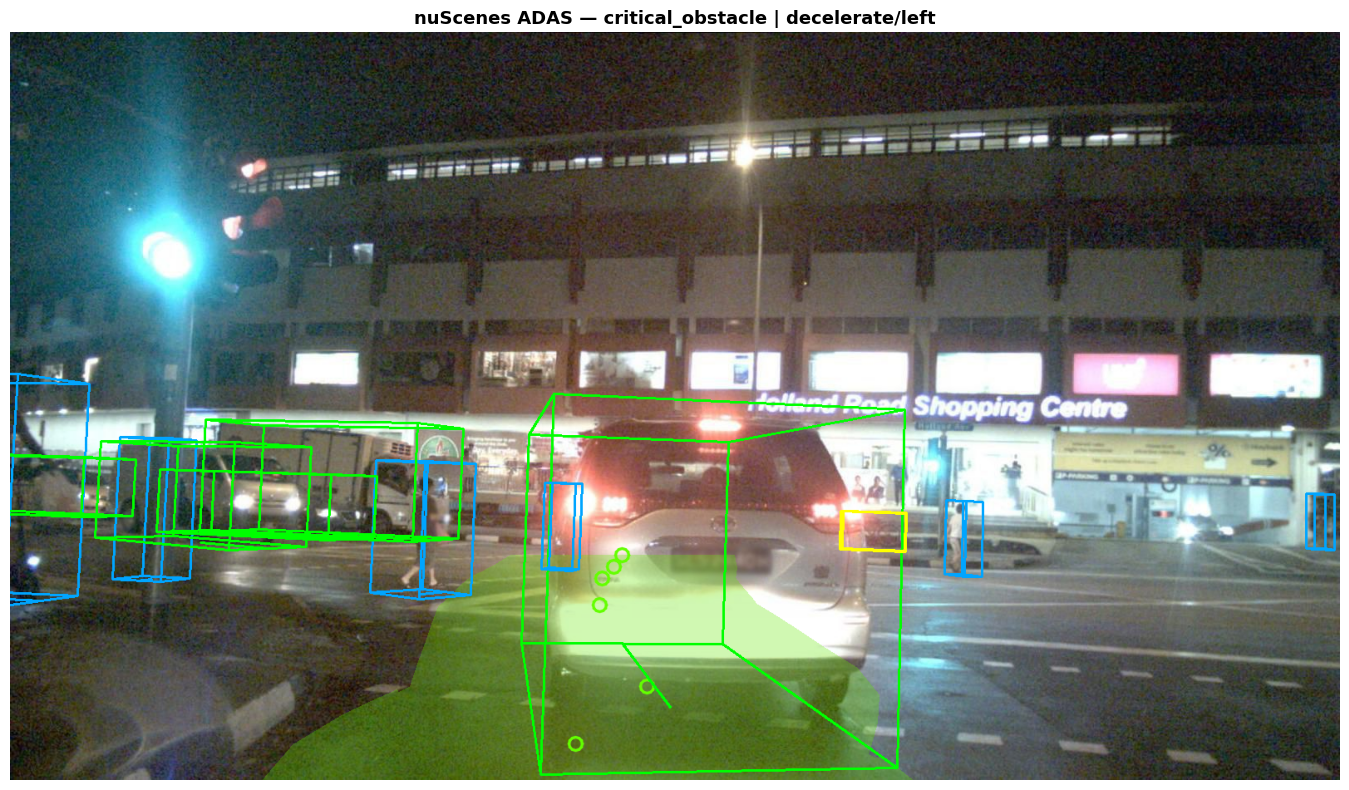

Green corridor = predicted path | 3D boxes = detected objects


In [15]:
def wp_to_ego3d(wps, z=0.0):
    e = np.zeros((len(wps), 3))
    e[:,0] = wps[:,1]    # forward
    e[:,1] = -wps[:,0]   # left (BEV x is right-positive)
    e[:,2] = z
    return e

def project_ego_to_cam(points_ego, nusc, cam_token):
    sd = nusc.get('sample_data', cam_token)
    cs = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    K = np.array(cs['camera_intrinsic'])
    cam_t = np.array(cs['translation'])
    cam_q = Quaternion(cs['rotation'])
    px, depths = [], []
    for p in points_ego:
        pc = cam_q.inverse.rotate(p - cam_t)
        depths.append(pc[2])
        if pc[2] > 0.1:
            uv = K @ pc
            px.append([uv[0]/uv[2], uv[1]/uv[2]])
        else:
            px.append([np.nan, np.nan])
    return np.array(px), np.array(depths)

def corridor_ego(wps, width=1.4, z=0.0, n=40):
    full = np.vstack([[[0,0,0]], wps[:,:3]])
    t0=np.linspace(0,1,len(full)); ts=np.linspace(0,1,n)
    cx=np.interp(ts,t0,full[:,0]); cy=np.interp(ts,t0,full[:,1])
    L,R=[],[]
    for i in range(len(cx)):
        if i<len(cx)-1: dx,dy=cx[i+1]-cx[i],cy[i+1]-cy[i]
        else: dx,dy=cx[i]-cx[i-1],cy[i]-cy[i-1]
        ln=np.sqrt(dx**2+dy**2)+1e-6; ox,oy=-dy/ln*width,dx/ln*width
        L.append([cx[i]-ox,cy[i]-oy,0]); R.append([cx[i]+ox,cy[i]+oy,0])
    le=np.array(L); re=np.array(R)
    le[:,2]=z; re[:,2]=z
    # already in BEV; convert to ego3d
    le3=np.column_stack([le[:,1],-le[:,0],np.full(len(le),z)])
    re3=np.column_stack([re[:,1],-re[:,0],np.full(len(re),z)])
    return le3, re3

# ── Single-frame test ──
d = traj_data['test'][0]
cam_token = nusc.get('sample', d['sample_token'])['data']['CAM_FRONT']
img = cv2.imread(d['cam_path']); H,W = img.shape[:2]

# Predicted corridor
le, re_ = corridor_ego(d['pred']['waypoints'])
lpx,_ = project_ego_to_cam(le, nusc, cam_token)
rpx,_ = project_ego_to_cam(re_, nusc, cam_token)
valid = lambda p: ~np.isnan(p[:,0]) & (p[:,0]>=-500)&(p[:,0]<W+500)
lv, rv = valid(lpx), valid(rpx)
if lv.sum()>2 and rv.sum()>2:
    poly = np.vstack([lpx[lv], rpx[rv][::-1]]).astype(np.int32)
    ov = img.copy(); cv2.fillPoly(ov,[poly],(0,230,100)); img=cv2.addWeighted(ov,0.3,img,0.7,0)

# Predicted waypoints
wpx,_ = project_ego_to_cam(wp_to_ego3d(d['pred']['waypoints']), nusc, cam_token)
for j in range(len(wpx)):
    if not np.isnan(wpx[j,0]) and 0<=wpx[j,0]<W and 0<=wpx[j,1]<H:
        cv2.circle(img,(int(wpx[j,0]),int(wpx[j,1])),8,(0,255,100),2,cv2.LINE_AA)

# 3D boxes
cls_col={'car':(0,255,0),'pedestrian':(0,165,255),'truck':(0,255,255),'bus':(0,255,255),'bicycle':(255,255,0),'motorcycle':(255,0,255)}
for det in d['detections'][:12]:
    c=cls_col.get(det['class'],(255,255,255))
    det['box3d'].render_cv2(img,view=d['cam_intrinsic'],normalize=True,colors=(c,c,c))

plt.figure(figsize=(16,8)); plt.imshow(img[:,:,::-1])
plt.title(f"nuScenes ADAS — {d['scenario']} | {d['pred']['speed']}/{d['pred']['steer']}",fontsize=13,fontweight='bold')
plt.axis('off'); plt.tight_layout()
plt.savefig('/content/nusc_adas_test.png',dpi=150,bbox_inches='tight'); plt.show()
print("Green corridor = predicted path | 3D boxes = detected objects")

## 11. Simulation video

Renders a three-panel view per scene — camera with 3D boxes + planned corridor, bird's-eye trajectory (predicted vs real), and the VLA decision panel (perceive → reason → act, plus speed / TTC / deceleration / regen and the safety score). Writes an MP4 (animated) and a GIF (one held frame per scene). The longitudinal control is derived from the predicted trajectory, so it always agrees with the action head's speed command.

Render:   0%|          | 0/16 [00:00<?, ?it/s]

Saved cot_vla_nuscenes.mp4 and .gif  |  ADE 2.9m · steer 82% · safety 71/100


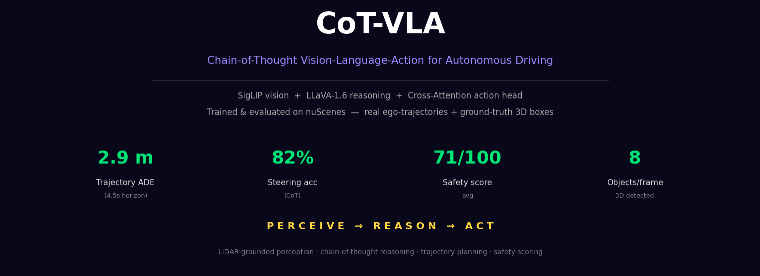

In [16]:
import imageio, gc, shutil
from collections import defaultdict
from IPython.display import Image as IPImage, display

# --- Derive longitudinal control (speed, TTC, deceleration, EV regen) from the
#     predicted trajectory. Everything here is consistent with the action head's
#     speed command, so the displayed control never contradicts the model. ---
KEYFRAME_DT = 0.5   # nuScenes keyframes are 2 Hz

def compute_kinematics(d):
    wps = d['pred']['waypoints']
    pts = np.vstack([[0, 0], wps[:, :2]])
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    speeds = seg / KEYFRAME_DT
    v_now, v_end = float(speeds[0]), float(speeds[-1])
    decel = max((v_now - v_end) / (len(speeds) * KEYFRAME_DT), 0.0)   # avg decel along the plan
    pred_speed = d['pred']['speed']

    lead = next((x for x in d['detections']
                 if x['box3d'].center[2] > 0 and abs(x['box3d'].center[0]) < 2.5), None)
    ttc = lead_dist = lead_cls = None
    if lead and v_now > 0.5:
        lead_dist, lead_cls = float(lead['box3d'].center[2]), lead['class']
        ttc = lead_dist / v_now

    regen = None
    if pred_speed == 'maintain':
        action = 'maintain speed'
    elif pred_speed == 'decelerate':
        action = 'decelerate'
        regen = 'Regen L1 (light)' if decel < 0.8 else 'Regen L2 (moderate)' if decel < 2.0 else 'Regen L3 (strong)'
    else:  # stop
        action = 'holding (stopped)' if v_now < 1.0 else 'braking to stop'
        regen = None if v_now < 1.0 else 'Regen L3 + friction'

    turn_dist = None
    if d['scenario'] in ('turn_left', 'turn_right'):
        for w in wps:
            if abs(float(w[0])) > 1.5:
                turn_dist = float(w[1]); break

    return {'speed_kmh': v_now * 3.6, 'ttc': ttc, 'decel': decel, 'action': action,
            'regen': regen, 'lead_dist': lead_dist, 'lead_class': lead_cls, 'turn_dist': turn_dist}

for d in traj_data['test']:
    d['kin'] = compute_kinematics(d)

# --- Pick the clearest few frames per scenario so the reel stays tight ---
by_sc = defaultdict(list)
for i, d in enumerate(traj_data['test']):
    ade = float(np.mean(np.linalg.norm(d['pred']['waypoints'][:, :2] - d['waypoints'][:, :2], axis=1)))
    has_cot = len(d['cot']['perception']) > 12 and len(d['cot']['reasoning']) > 12
    score = (100 if has_cot else 0) - ade + len(d['detections']) * 0.6
    by_sc[d['scenario']].append((score, i))
curated = []
for sc, items in by_sc.items():
    items.sort(reverse=True)
    curated += [i for _, i in items[:3]]
prio = ['clear_road', 'vehicle_ahead', 'turn_left', 'turn_right', 'pedestrian_near', 'critical_obstacle', 'stopped']
curated.sort(key=lambda i: prio.index(traj_data['test'][i]['scenario'])
             if traj_data['test'][i]['scenario'] in prio else 99)
ordered = curated

cls_bgr = {'car': (0, 255, 0), 'pedestrian': (0, 165, 255), 'truck': (0, 255, 255),
           'bus': (0, 255, 255), 'bicycle': (255, 255, 0), 'motorcycle': (255, 0, 255)}
cls_rgb = {k: (v[2] / 255, v[1] / 255, v[0] / 255) for k, v in cls_bgr.items()}
SAFFRON = (51, 153, 255)
FIG, DPI, TARGET = (16, 5.8), 95, (1520, 552)

ades = [float(np.mean(np.linalg.norm(d['pred']['waypoints'][:, :2] - d['waypoints'][:, :2], axis=1)))
        for d in traj_data['test']]
mean_ade = np.mean(ades)
cot_st = np.mean([d['cot']['steering_command'] == d['steer'] for d in traj_data['test']]) * 100
avg_saf = np.mean([d['safety']['overall_score'] for d in traj_data['test']])
n_obj = int(np.mean([len(d['detections']) for d in traj_data['test']]))

def fig_to_frame(fig):
    fig.canvas.draw()
    fr = np.array(fig.canvas.buffer_rgba())[:, :, :3].copy()
    plt.close(fig)
    return cv2.resize(fr, TARGET)

def wrap(t, n=22, mx=3):
    words = t.split(); lines, c = [], ''
    for w in words:
        if len(c + ' ' + w) > n:
            lines.append(c); c = w
        else:
            c = (c + ' ' + w).strip()
    lines.append(c)
    truncated = len(lines) > mx
    lines = lines[:mx]
    if truncated:
        last = lines[-1].split()
        while last and last[-1].lower() in ('a', 'an', 'the', 'and', 'at', 'of', 'with', 'on', 'to', 'is', 'are', ','):
            last = last[:-1]
        lines[-1] = (' '.join(last) + ' …') if last else '…'
    return lines

def render_cam(d):
    cam_token = nusc.get('sample', d['sample_token'])['data']['CAM_FRONT']
    img = cv2.imread(d['cam_path']); H, W = img.shape[:2]
    le, re_ = corridor_ego(d['pred']['waypoints'])
    lpx, _ = project_ego_to_cam(le, nusc, cam_token)
    rpx, _ = project_ego_to_cam(re_, nusc, cam_token)
    vL, vR = ~np.isnan(lpx[:, 0]), ~np.isnan(rpx[:, 0])
    if vL.sum() > 2 and vR.sum() > 2:
        poly = np.vstack([lpx[vL], rpx[vR][::-1]]).astype(np.int32)
        ov = img.copy(); cv2.fillPoly(ov, [poly], (0, 230, 100)); img = cv2.addWeighted(ov, 0.3, img, 0.7, 0)
    wpx, _ = project_ego_to_cam(wp_to_ego3d(d['pred']['waypoints']), nusc, cam_token)
    for j in range(len(wpx)):
        if not np.isnan(wpx[j, 0]) and 0 <= wpx[j, 0] < W and 0 <= wpx[j, 1] < H:
            cv2.circle(img, (int(wpx[j, 0]), int(wpx[j, 1])), 7, (0, 255, 100), 2, cv2.LINE_AA)
    near = sorted(d['detections'], key=lambda x: x['distance'])
    label_set = {id(x) for x in near[:6] if x['distance'] < 35}
    for det in d['detections'][:12]:
        c = cls_bgr.get(det['class'], (255, 255, 255))
        det['box3d'].render_cv2(img, view=d['cam_intrinsic'], normalize=True, colors=(c, c, c))
        if id(det) in label_set:
            corners = det['box3d'].corners(); pts = d['cam_intrinsic'] @ corners; pts = pts[:2] / pts[2]
            u, v = int(pts[0].mean()), int(pts[1].min())
            if 0 <= u < W and 0 <= v < H:
                txt, pos = f"{det['distance']:.0f}m", (u - 16, max(v - 8, 18))
                cv2.putText(img, txt, pos, cv2.FONT_HERSHEY_SIMPLEX, 0.78, (0, 0, 0), 5, cv2.LINE_AA)
                cv2.putText(img, txt, pos, cv2.FONT_HERSHEY_SIMPLEX, 0.78, SAFFRON, 2, cv2.LINE_AA)
    return img

def make_intro():
    fig = plt.figure(figsize=FIG, facecolor='#08081a', dpi=DPI)
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_facecolor('#08081a'); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.text(0.5, 0.88, 'CoT-VLA', fontsize=44, color='white', ha='center', fontweight='bold')
    ax.text(0.5, 0.77, 'Chain-of-Thought Vision-Language-Action for Autonomous Driving', fontsize=16, color='#9E87FF', ha='center')
    ax.plot([0.2, 0.8], [0.71, 0.71], color='#333', lw=1)
    ax.text(0.5, 0.645, 'SigLIP vision  +  LLaVA-1.6 reasoning  +  Cross-Attention action head', fontsize=12.5, color='#aaa', ha='center')
    ax.text(0.5, 0.585, 'Trained & evaluated on nuScenes  —  real ego-trajectories + ground-truth 3D boxes', fontsize=12.5, color='#aaa', ha='center')
    tiles = [(f'{mean_ade:.1f} m', 'Trajectory ADE', '(4.5s horizon)'), (f'{cot_st:.0f}%', 'Steering acc', '(CoT)'),
             (f'{avg_saf:.0f}/100', 'Safety score', 'avg'), (f'{n_obj}', 'Objects/frame', '3D detected')]
    for (val, lab, sub), x in zip(tiles, [0.165, 0.385, 0.615, 0.835]):
        ax.text(x, 0.41, val, fontsize=27, color='#00E676', ha='center', fontweight='bold')
        ax.text(x, 0.33, lab, fontsize=12, color='#ddd', ha='center')
        ax.text(x, 0.285, sub, fontsize=9.5, color='#888', ha='center')
    ax.text(0.5, 0.17, 'P E R C E I V E   →   R E A S O N   →   A C T', fontsize=15, color='#FFD740', ha='center', fontweight='bold')
    ax.text(0.5, 0.08, 'LiDAR-grounded perception · chain-of-thought reasoning · trajectory planning · safety scoring', fontsize=10.5, color='#777', ha='center')
    return fig_to_frame(fig)

sc_c = {'critical_obstacle': '#FF5252', 'pedestrian_near': '#FF9100', 'vehicle_ahead': '#FFD740',
        'stopped': '#FF5252', 'turn_left': '#448AFF', 'turn_right': '#7C4DFF', 'clear_road': '#00E676'}
SPD = {'maintain': 'MAINTAIN', 'decelerate': 'DECELERATE', 'stop': 'STOP'}
STD = {'straight': 'STRAIGHT', 'left': 'LEFT', 'right': 'RIGHT'}
rc = {'LOW': '#00E676', 'MEDIUM': '#FFD740', 'HIGH': '#FF9100', 'CRITICAL': '#FF5252'}

def make_scene_frame(d, sf, sn):
    wp_p, wp_g, nw, kin = d['pred']['waypoints'], d['waypoints'], len(d['pred']['waypoints']), d['kin']
    cam = render_cam(d)
    objs = sorted([(x['box3d'].center[0], x['box3d'].center[2], x['class'], x['distance'])
                   for x in d['detections']], key=lambda o: o[3])[:6]
    px_ = np.concatenate([[0], wp_p[:, 0]]); py_ = np.concatenate([[0], wp_p[:, 1]])
    gx_ = np.concatenate([[0], wp_g[:, 0]]); gy_ = np.concatenate([[0], wp_g[:, 1]])
    t0 = np.linspace(0, 1, len(px_)); ts = np.linspace(0, 1, 50)
    spx, spy = np.interp(ts, t0, px_), np.interp(ts, t0, py_)
    sgx, sgy = np.interp(ts, t0, gx_), np.interp(ts, t0, gy_)
    ade = np.mean(np.linalg.norm(wp_p[:, :2] - wp_g[:, :2], axis=1)); ns = max(int(sf * len(spx)), 2)

    fig = plt.figure(figsize=FIG, facecolor='#08081a', dpi=DPI)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.28, 0.68, 0.6], wspace=0.06)

    ax1 = fig.add_subplot(gs[0]); ax1.imshow(cam[:, :, ::-1]); ax1.axis('off')

    ax2 = fig.add_subplot(gs[1]); ax2.set_facecolor('#12122a')
    ym = max(np.max(np.abs(py_)), np.max(np.abs(gy_)), 25) + 5
    ax2.set_xlim(-16, 16); ax2.set_ylim(-4, min(ym, 55)); ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.15, color='#555', linewidth=0.6)
    ax2.set_title("BIRD'S-EYE VIEW", fontsize=11, color='#aaa', fontweight='bold', pad=6)
    for ox, oy, oc, od in objs:
        if 0 < oy < min(ym, 55) and abs(ox) < 16:
            ax2.scatter(ox, oy, c=[cls_rgb.get(oc, (1, 1, 1))], s=100, marker='s', edgecolors='white', linewidths=1, zorder=5)
            ax2.text(ox, oy + 1.3, f"{oc[:3]} {od:.0f}m", fontsize=7, color='white', ha='center', zorder=6)
    ax2.plot(sgx[:ns], sgy[:ns], '--', color='#FF6B6B', lw=3, alpha=0.85, label='Real path (GT)', zorder=3)
    for i in range(ns - 1):
        t = i / max(ns - 2, 1); col = (0.1 - 0.1 * t, 0.5 + 0.4 * t, 1.0 - 0.6 * t)
        ax2.plot([spx[i], spx[i + 1]], [spy[i], spy[i + 1]], color=col, lw=7, alpha=0.3, solid_capstyle='round', zorder=6)
        ax2.plot([spx[i], spx[i + 1]], [spy[i], spy[i + 1]], color=col, lw=3.5, alpha=0.95, solid_capstyle='round', zorder=7)
    ax2.plot([], [], color='#00E676', lw=3.5, label='Predicted path')
    for j in range(nw):
        if sf >= (j + 1) / nw:
            ax2.plot(wp_p[j, 0], wp_p[j, 1], 'o', color='#00E676', ms=9, markeredgecolor='white', markeredgewidth=1.4, zorder=8)
    ax2.plot(0, 0, '^', color='#7C4DFF', ms=15, markeredgecolor='white', markeredgewidth=2, zorder=10)
    ax2.text(0, -2.6, 'EGO', ha='center', fontsize=9, color='#b3a0ff', fontweight='bold')
    ax2.text(0.03, 0.97, f'ADE {ade:.1f}m', transform=ax2.transAxes, fontsize=12, color='#fff', ha='left', va='top',
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='#000', alpha=0.6, edgecolor='none'))
    ax2.legend(loc='lower left', fontsize=8.5, facecolor='#12122a', edgecolor='#555', labelcolor='white', framealpha=0.95)
    ax2.set_xlabel('Lateral (m)', fontsize=10, color='#888'); ax2.set_ylabel('Forward (m)', fontsize=10, color='#888')
    ax2.tick_params(colors='#888', labelsize=8)
    for s in ax2.spines.values(): s.set_visible(True); s.set_color('#555'); s.set_linewidth(1.2)

    ax3 = fig.add_subplot(gs[2]); ax3.set_facecolor('#0e0e22'); ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis('off')
    ax3.text(0.5, 0.985, 'VLA DECISION', fontsize=11, color='#08081a', ha='center', va='top', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='#00E676', edgecolor='none'))
    y = 0.90
    ax3.text(0.5, y, d['scenario'].replace('_', ' ').upper(), fontsize=13, color=sc_c.get(d['scenario'], '#aaa'), ha='center', fontweight='bold'); y -= 0.043
    ax3.text(0.5, y, d['scene'], fontsize=9, color='#777', ha='center'); y -= 0.034
    ax3.plot([0.05, 0.95], [y, y], color='#333', lw=1); y -= 0.034
    ax3.text(0.06, y, 'PERCEIVE', fontsize=11, color='#5AA0FF', fontweight='bold', va='top'); y -= 0.037
    pl = wrap(d['cot']['perception']); ax3.text(0.06, y, '\n'.join(pl), fontsize=9.5, color='#aaccee', va='top', linespacing=1.3); y -= 0.032 * len(pl) + 0.022
    ax3.text(0.06, y, 'REASON', fontsize=11, color='#FFD740', fontweight='bold', va='top'); y -= 0.037
    rl = wrap(d['cot']['reasoning']); ax3.text(0.06, y, '\n'.join(rl), fontsize=9.5, color='#ffe0a0', va='top', linespacing=1.3); y -= 0.032 * len(rl) + 0.022
    if sf >= 1.0:
        ax3.text(0.06, y, 'ACT', fontsize=11, color='#00E676', fontweight='bold', va='top'); y -= 0.037
        ax3.text(0.06, y, f"Speed:  {SPD[d['pred']['speed']]}", fontsize=9.5, color='#7FC8FF', va='top', fontweight='bold'); y -= 0.032
        ax3.text(0.06, y, f"Steer:  {STD[d['pred']['steer']]}", fontsize=9.5, color='#7FC8FF', va='top', fontweight='bold'); y -= 0.04
        ax3.text(0.06, y, 'CONTROL', fontsize=11, color='#FF9100', fontweight='bold', va='top'); y -= 0.037
        lines = [f"Ego speed: {kin['speed_kmh']:.0f} km/h"]
        if kin['ttc'] is not None: lines.append(f"Lead {kin['lead_class']} {kin['lead_dist']:.0f}m · TTC {kin['ttc']:.1f}s")
        lines.append(f"Action: {kin['action']}")
        if kin['regen']: lines.append(f"EV: {kin['regen']}")
        if kin['turn_dist'] is not None: lines.append(f"Turn in {kin['turn_dist']:.0f} m")
        ax3.text(0.06, y, '\n'.join(lines[:4]), fontsize=9, color='#ffc38a', va='top', linespacing=1.3); y -= 0.032 * len(lines[:4]) + 0.02
        ax3.text(0.06, y, f"SAFETY {d['safety']['overall_score']:.0f}/100", fontsize=11, color=rc.get(d['safety']['risk_level'], '#888'), va='top', fontweight='bold')
    for s in ax3.spines.values(): s.set_visible(True); s.set_color('#333')

    fig.suptitle('CoT-VLA on nuScenes — Real Trajectory + Chain-of-Thought + TTC/Regen Control', fontsize=13.5, fontweight='bold', color='white', y=0.99)
    fig.text(0.99, 0.01, f'{sn + 1}/{len(ordered)}', fontsize=9, color='#555', ha='right')
    fig.patch.set_facecolor('#08081a'); plt.subplots_adjust(left=0.01, right=0.99, top=0.90, bottom=0.07, wspace=0.06)
    return fig_to_frame(fig)

# --- Render: animated path reveal for the video, final frame held for the GIF ---
mp4 = imageio.get_writer('/content/cot_vla_nuscenes.mp4', fps=2, codec='libx264', quality=8, pixelformat='yuv420p')
gif_frames = []

intro = make_intro()
for _ in range(10): mp4.append_data(intro)
for _ in range(2): gif_frames.append(intro[::2, ::2])
del intro; gc.collect()

for sn, idx in enumerate(tqdm(ordered, desc="Render")):
    d = traj_data['test'][idx]
    reveal, final = make_scene_frame(d, 0.5, sn), make_scene_frame(d, 1.0, sn)
    for _ in range(3): mp4.append_data(reveal)
    for _ in range(8): mp4.append_data(final)
    for _ in range(4): gif_frames.append(final[::2, ::2])
    del reveal, final; gc.collect()

mp4.close()
imageio.mimsave('/content/cot_vla_nuscenes.gif', gif_frames, fps=1, loop=0)
print(f"Saved cot_vla_nuscenes.mp4 and .gif  |  ADE {mean_ade:.1f}m · steer {cot_st:.0f}% · safety {avg_saf:.0f}/100")
display(IPImage(filename='/content/cot_vla_nuscenes.gif'))